<a href="https://colab.research.google.com/github/hjfuentes/Laboratorio-Datos-Sociales/blob/main/MineriaDatosIntro/Sesion5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Exploratorio de Datos — Sample Superstore

## Objetivo de la clase

En este notebook trabajaremos con el dataset **Sample Superstore**, un conjunto de datos comercial que simula ventas de una tienda minorista.

El objetivo no es construir un modelo predictivo, sino aprender a realizar un **análisis exploratorio de datos** usando estadística descriptiva.

Al finalizar, el alumno debería poder responder preguntas como:

1. ¿Cuánto vende la empresa?
2. ¿Qué regiones concentran mayores ventas?
3. ¿Qué categorías generan más utilidad?
4. ¿Dónde se observan pérdidas?
5. ¿Qué variables presentan mayor dispersión?
6. ¿Qué patrones iniciales se pueden comunicar al negocio?

## 1. Importación de librerías

Primero cargaremos las librerías principales.

- `pandas`: permite leer, transformar y resumir datos.
- `numpy`: permite realizar operaciones numéricas.
- `matplotlib` y `seaborn`: permiten construir gráficos para el análisis exploratorio.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

## 2. Carga del dataset

Usaremos una versión pública del dataset **Sample Superstore** disponible en GitHub.

La ventaja de usar una URL directa es que el alumno puede ejecutar el notebook sin descargar manualmente el archivo.

In [ ]:
#pd.read_csv("SampleSuperstore.csv")

In [ ]:
url = "https://raw.githubusercontent.com/Wunmi-O/Superstore/master/SampleSuperstore.csv"

In [ ]:
pd.read_csv(url)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub_Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.96,2.00,0.00,41.91
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.94,3.00,0.00,219.58
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.62,2.00,0.00,6.87
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.58,5.00,0.45,-383.03
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.37,2.00,0.20,2.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.25,3.00,0.20,4.10
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.96,2.00,0.00,15.63
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.58,2.00,0.20,19.39
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.60,4.00,0.00,13.32


In [ ]:
data = pd.read_csv(url)
data.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub_Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.96,2.00,0.00,41.91
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.94,3.00,0.00,219.58
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.62,2.00,0.00,6.87
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.58,5.00,0.45,-383.03
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.37,2.00,0.20,2.52


In [ ]:
data.tail()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub_Category,Sales,Quantity,Discount,Profit
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.25,3.00,0.20,4.10
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.96,2.00,0.00,15.63
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.58,2.00,0.20,19.39
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.60,4.00,0.00,13.32
9993,Second Class,Consumer,United States,Westminster,California,92683,West,Office Supplies,Appliances,243.16,2.00,0.00,72.95


## 3. Revisión inicial de la estructura

Antes de calcular indicadores, debemos conocer la estructura del dataset.

En esta sección revisaremos:

- Número de filas y columnas.
- Nombre de las variables.
- Tipo de dato de cada columna.
- Valores faltantes.

In [ ]:
print("Filas y columnas:", data.shape)
data.info()

Filas y columnas: (9994, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub_Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   float64
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 1015.1+ KB


In [ ]:
data.isna().sum()#.sort_values(ascending=False)

,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub_Category,0
Sales,0


## 4. Limpieza básica de nombres de columnas

Para trabajar con mayor comodidad, convertiremos los nombres de columnas a un formato más práctico:

- Minúsculas.
- Sin espacios.
- Con guion bajo.

Esto evita errores al escribir nombres de variables en el código.

In [ ]:
"        Postal-Code  ".strip().lower().replace(" ", "_").replace("-", "_")

'postal_code'

In [ ]:
data.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("-", "_")

Index(['ship_mode', 'segment', 'country', 'city', 'state', 'postal_code',
       'region', 'category', 'sub_category', 'sales', 'quantity', 'discount',
       'profit'],
      dtype='object')

In [ ]:
data.columns = (
    data.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

data.columns

Index(['ship_mode', 'segment', 'country', 'city', 'state', 'postal_code',
       'region', 'category', 'sub_category', 'sales', 'quantity', 'discount',
       'profit'],
      dtype='object')

## 5. Identificación de variables numéricas y categóricas

En un análisis exploratorio es importante separar las variables según su tipo.

Las variables numéricas permiten calcular medias, medianas, desviaciones estándar, mínimos y máximos.

Las variables categóricas permiten realizar conteos, proporciones y comparaciones por grupo.

In [ ]:
numericas = data.select_dtypes(include="number").columns.tolist()
categoricas = data.select_dtypes(exclude="number").columns.tolist()

print("Variables numéricas:")
print(numericas)

print("\nVariables categóricas:")
print(categoricas)

Variables numéricas:
['postal_code', 'sales', 'quantity', 'discount', 'profit']

Variables categóricas:
['ship_mode', 'segment', 'country', 'city', 'state', 'region', 'category', 'sub_category']


In [ ]:
data.postal_code.value_counts()

,count
postal_code,
10035,263
10024,230
10009,229
94122,203
10011,193
...,...
61761,1
79605,1
72762,1


## 6. Estadística descriptiva general

Ahora revisaremos las principales medidas descriptivas de las variables numéricas.

Presta atención a:

- **Media**: valor promedio.
- **Mediana**: valor central.
- **Desviación estándar**: nivel de dispersión.
- **Mínimo y máximo**: valores extremos.
- **Cuartiles**: distribución de los datos.

In [ ]:
data[['postal_code', 'sales', 'quantity', 'discount', 'profit']].describe()

,postal_code,sales,quantity,discount,profit
count,"9,994.00","9,994.00","9,994.00","9,994.00","9,994.00"
mean,"55,190.38",229.86,3.79,0.16,28.66
std,"32,063.69",623.25,2.23,0.21,234.26
min,"1,040.00",0.44,1.00,0.00,"-6,599.98"
25%,"23,223.00",17.28,2.00,0.00,1.73
50%,"56,430.50",54.49,3.00,0.20,8.66
75%,"90,008.00",209.94,5.00,0.20,29.36
max,"99,301.00","22,638.48",14.00,0.80,"8,399.98"


In [ ]:
data[numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
postal_code,"9,994.00","55,190.38","32,063.69","1,040.00","23,223.00","56,430.50","90,008.00","99,301.00"
sales,"9,994.00",229.86,623.25,0.44,17.28,54.49,209.94,"22,638.48"
quantity,"9,994.00",3.79,2.23,1.00,2.00,3.00,5.00,14.00
discount,"9,994.00",0.16,0.21,0.00,0.00,0.20,0.20,0.80
profit,"9,994.00",28.66,234.26,"-6,599.98",1.73,8.66,29.36,"8,399.98"


<Axes: >

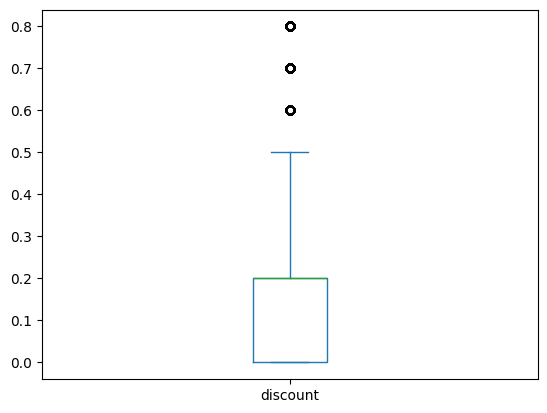

In [ ]:
data.discount.plot.box()

<Axes: >

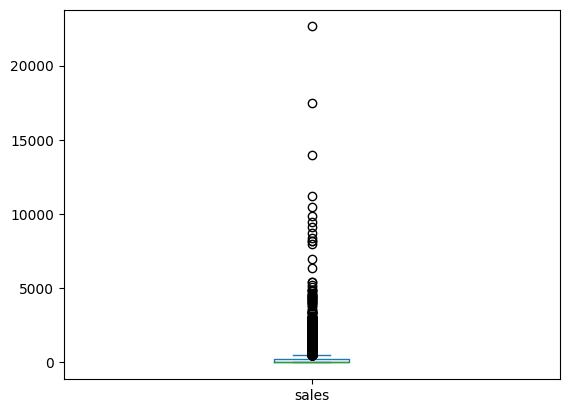

In [ ]:
data.sales.plot.box()

<Axes: >

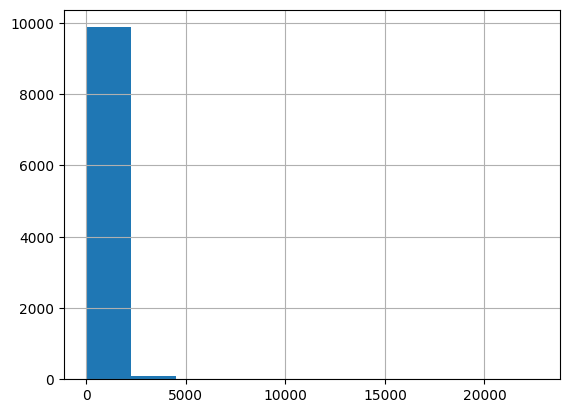

In [ ]:
data.sales.hist()

In [ ]:
q1,q3 = data.quantity.quantile([0.25,0.75])

In [ ]:
iqr = q3 - q1
ls = q3 + 1.5*iqr
li = q1 - 1.5*iqr
prom = data.quantity.mean()
sd = data.quantity.std()

In [ ]:
ls

9.5

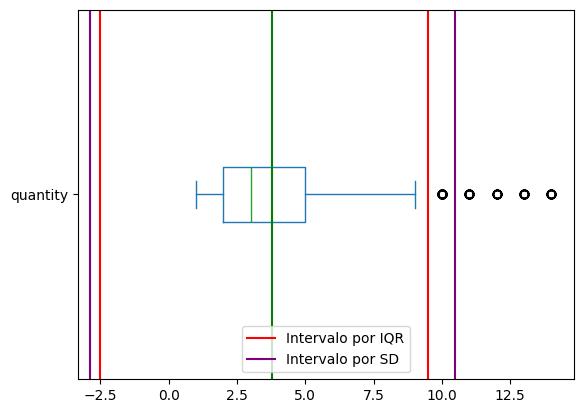

In [ ]:
data.quantity.plot.box(vert=False)
plt.axvline(ls, color="red",label='Intervalo por IQR')
plt.axvline(li, color="red")
plt.axvline(prom, color="g")
plt.axvline(prom+3*sd, color="purple",label='Intervalo por SD')
plt.axvline(prom-3*sd, color="purple")
plt.legend()
plt.show()

## 7. Indicadores comerciales principales

En negocios, el análisis descriptivo debe traducirse en indicadores claros.

Calcularemos:

- Ventas totales.
- Utilidad total.
- Cantidad total vendida.
- Descuento promedio.
- Margen de utilidad aproximado.

In [ ]:
data.postal_code.nunique()

631

<Axes: xlabel='postal_code'>

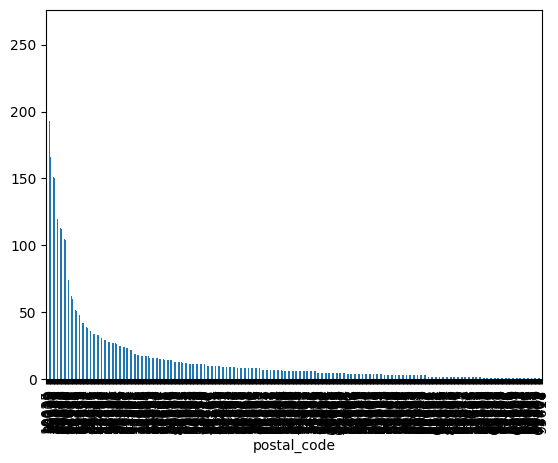

In [ ]:
data.postal_code.value_counts().plot(kind='bar')

In [ ]:
data["sales"].sum()

np.float64(2297201.07)

In [ ]:
ventas_totales = data["sales"].sum()
utilidad_total = data["profit"].sum()
cantidad_total = data["quantity"].sum()
descuento_promedio = data["discount"].mean()
margen_utilidad = utilidad_total / ventas_totales

indicadores = pd.DataFrame({
    "Indicador": [
        "Ventas totales",
        "Utilidad total",
        "Cantidad total vendida",
        "Descuento promedio",
        "Margen de utilidad"
    ],
    "Valor": [
        ventas_totales,
        utilidad_total,
        cantidad_total,
        descuento_promedio,
        margen_utilidad
    ]
})

indicadores

,Indicador,Valor
0,Ventas totales,"2,297,201.07"
1,Utilidad total,"286,397.79"
2,Cantidad total vendida,"37,873.00"
3,Descuento promedio,0.16
4,Margen de utilidad,0.12


In [ ]:
pd.DataFrame({'numeros':[1,2,3],'letras':['a','b','c']})

,numeros,letras
0,1,a
1,2,b
2,3,c


## 8. Análisis por categoría

Ahora agruparemos los datos por categoría de producto.

Esto nos permite comparar el desempeño comercial de cada línea de negocio.

Observa especialmente si la categoría con mayores ventas también es la más rentable.

In [ ]:
data.sales.sum()

np.float64(2297201.07)

In [ ]:
data.groupby("category").sales.sum()

,sales
category,
Furniture,"741,999.98"
Office Supplies,"719,046.99"
Technology,"836,154.10"


In [ ]:
tabla2 = data.groupby("category").aggregate({"sales":"sum","profit":"sum","quantity":'sum'}).assign(margen_de_utilidad=lambda x:x['profit']/x['sales'])#.to_excel("tabla_resumen.xlsx")
tabla2

,sales,profit,quantity,margen_de_utilidad
category,,,,
Furniture,"741,999.98","18,451.25","8,028.00",0.02
Office Supplies,"719,046.99","122,490.88","22,906.00",0.17
Technology,"836,154.10","145,455.66","6,939.00",0.17


In [ ]:
tabla2['margen'] = tabla2['profit']/tabla2['sales']
tabla2

,sales,profit,quantity,margen_de_utilidad,margen
category,,,,,
Furniture,"741,999.98","18,451.25","8,028.00",0.02,0.02
Office Supplies,"719,046.99","122,490.88","22,906.00",0.17,0.17
Technology,"836,154.10","145,455.66","6,939.00",0.17,0.17


In [ ]:
tabla2.sort_values('sales',ascending=False)

,sales,profit,quantity,margen_de_utilidad,margen
category,,,,,
Technology,"836,154.10","145,455.66","6,939.00",0.17,0.17
Furniture,"741,999.98","18,451.25","8,028.00",0.02,0.02
Office Supplies,"719,046.99","122,490.88","22,906.00",0.17,0.17


In [ ]:
resumen_categoria = (
    data.groupby("category")
    .agg(
        ventas=("sales", "sum"),
        utilidad=("profit", "sum"),
        cantidad=("quantity", "sum"),
        descuento_promedio=("discount", "mean")
    )
    .assign(margen_utilidad=lambda x: x["utilidad"] / x["ventas"])
    .sort_values("ventas", ascending=False)
)

resumen_categoria

,ventas,utilidad,cantidad,descuento_promedio,margen_utilidad
category,,,,,
Technology,"836,154.10","145,455.66","6,939.00",0.13,0.17
Furniture,"741,999.98","18,451.25","8,028.00",0.17,0.02
Office Supplies,"719,046.99","122,490.88","22,906.00",0.16,0.17


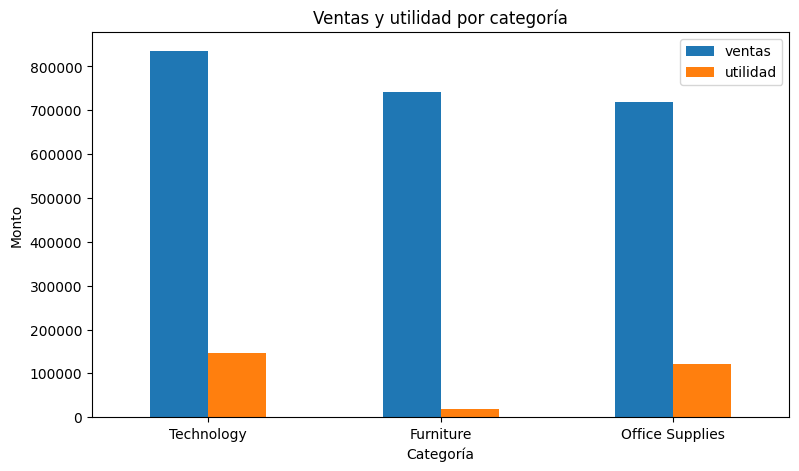

In [ ]:
resumen_categoria[["ventas", "utilidad"]].plot(kind="bar", figsize=(9, 5))
plt.title("Ventas y utilidad por categoría")
plt.xlabel("Categoría")
plt.ylabel("Monto")
plt.xticks(rotation=0)
plt.show()

## 9. Análisis por región

El análisis regional ayuda a identificar dónde se concentra el negocio.

Aquí evaluaremos ventas, utilidad y margen por región.

In [ ]:
resumen_region = (
    data.groupby("region")
    .agg(
        ventas=("sales", "sum"),
        utilidad=("profit", "sum"),
        cantidad=("quantity", "sum"),
        descuento_promedio=("discount", "mean")
    )
    .assign(margen_utilidad=lambda x: x["utilidad"] / x["ventas"])
    .sort_values("ventas", ascending=False)
)

resumen_region

,ventas,utilidad,cantidad,descuento_promedio,margen_utilidad
region,,,,,
West,"725,457.93","108,418.79","12,266.00",0.11,0.15
East,"678,781.36","91,522.84","10,618.00",0.15,0.13
Central,"501,239.88","39,706.45","8,780.00",0.24,0.08
South,"391,721.90","46,749.71","6,209.00",0.15,0.12


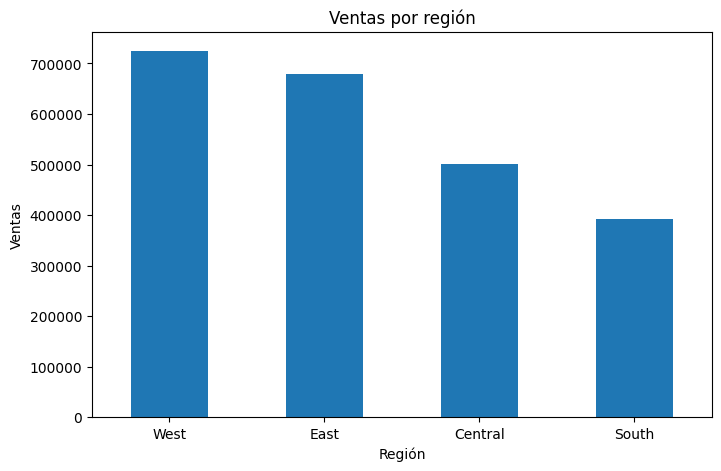

In [ ]:
resumen_region["ventas"].plot(kind="bar", figsize=(8, 5))
plt.title("Ventas por región")
plt.xlabel("Región")
plt.ylabel("Ventas")
plt.xticks(rotation=0)
plt.show()

## 10. Distribución de ventas y utilidad

No basta con mirar el total. También debemos observar cómo se distribuyen las operaciones.

En esta sección veremos si existen ventas muy pequeñas, ventas muy grandes o utilidades negativas.

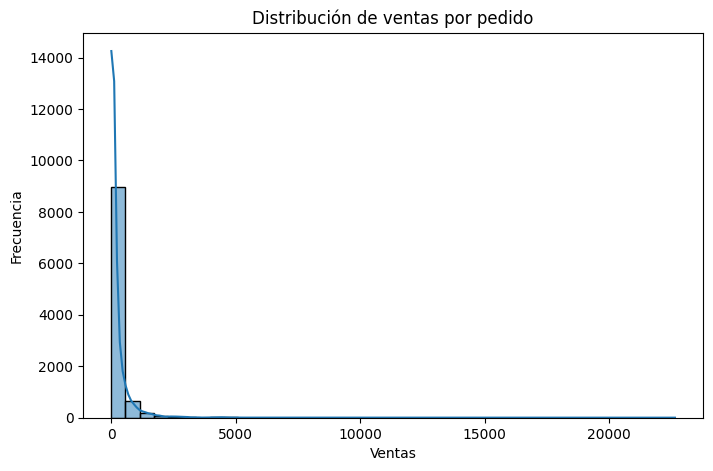

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data["sales"], bins=40, kde=True)
plt.title("Distribución de ventas por pedido")
plt.xlabel("Ventas")
plt.ylabel("Frecuencia")
plt.show()

### Analisis de Pareto

El **Análisis de Pareto** (o regla 80/20) establece que, para muchos eventos, aproximadamente el 80% de los efectos provienen del 20% de las causas. En este contexto, se busca identificar qué **20% de los productos, clientes, o regiones generan el 80% de las ventas o utilidades**, o bien, qué **20% de los problemas causan el 80% de las pérdidas**. Este análisis es crucial para enfocar los esfuerzos en las áreas de mayor impacto.

Ordenando la tabla de mayor a menor, segun ventas

Aplicar el metodo `sort.values()`

con doble corchete selecciono la lista de columnas `['sales']`

In [ ]:
tabla_pareto = data.sort_values('sales', ascending=False)[['sales']].reset_index(drop=True)
tabla_pareto

,sales
0,"22,638.48"
1,"17,499.95"
2,"13,999.96"
3,"11,199.97"
4,"10,499.97"
...,...
9989,0.88
9990,0.85
9991,0.84
9992,0.56


<Axes: >

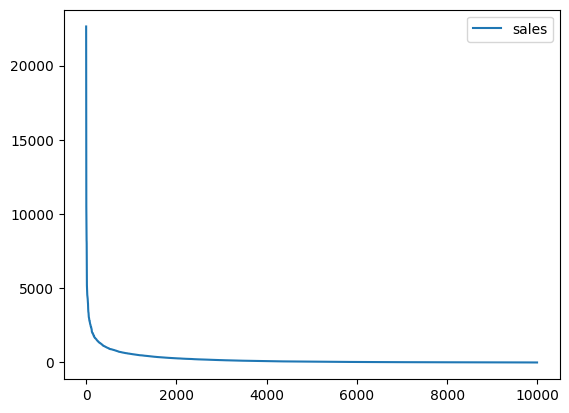

In [ ]:
tabla_pareto.plot()

In [ ]:
total_prod = tabla_pareto.shape[0]
total_ventas = tabla_pareto.sales.sum()
print(f"Total ventas {total_ventas}")
print(f"Total productos {total_prod}")

Total ventas 2297201.07
Total productos 9994


In [ ]:
tabla_pareto['sales_p'] = tabla_pareto['sales']/total_ventas*100

In [ ]:
tabla_pareto['sales_p_ac'] = tabla_pareto.sales_p.cumsum()

<Axes: >

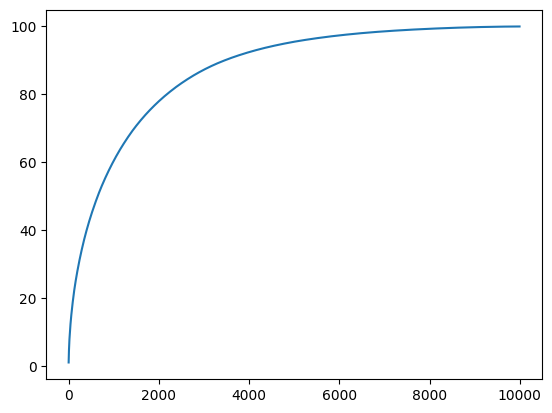

In [ ]:
tabla_pareto['sales_p_ac'].plot()

Calculando el % de productos

In [ ]:
tabla_pareto['ranking'] = tabla_pareto.index + 1

In [ ]:
tabla_pareto['ranking_p'] = tabla_pareto['ranking']/total_prod*100

In [ ]:
tabla_pareto

,sales,sales_p,sales_p_ac,ranking,ranking_ac,ranking_p
0,"22,638.48",0.99,0.99,1,1,0.01
1,"17,499.95",0.76,1.75,2,3,0.02
2,"13,999.96",0.61,2.36,3,6,0.03
3,"11,199.97",0.49,2.84,4,10,0.04
4,"10,499.97",0.46,3.30,5,15,0.05
...,...,...,...,...,...,...
9989,0.88,0.00,100.00,9990,49905045,99.96
9990,0.85,0.00,100.00,9991,49915036,99.97
9991,0.84,0.00,100.00,9992,49925028,99.98
9992,0.56,0.00,100.00,9993,49935021,99.99


<Axes: xlabel='ranking_p'>

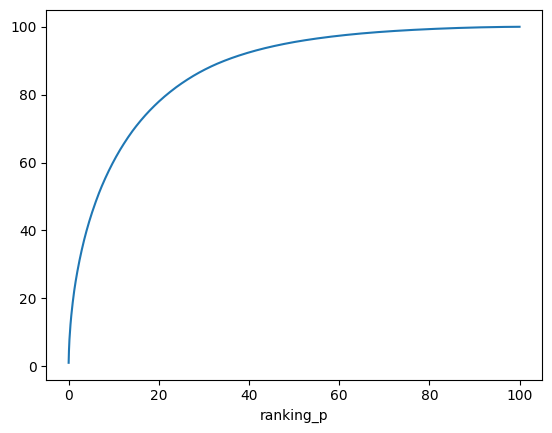

In [ ]:
tabla_pareto.set_index('ranking_p').sales_p_ac.plot()

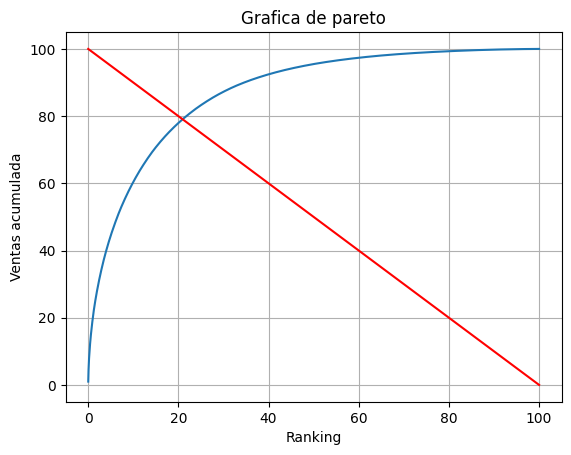

In [ ]:
fig,ax = plt.subplots()
ax.plot(tabla_pareto['ranking_p'],tabla_pareto['sales_p_ac'])
ax.plot([0,100],[100,0],c='red')
ax.grid()
ax.set_title("Grafica de pareto")
ax.set_xlabel("Ranking")
ax.set_ylabel("Ventas acumulada")
plt.show()

In [ ]:
tabla_pareto.query(" sales_p_ac > 80 ")

,sales,sales_p,sales_p_ac,ranking,ranking_ac,ranking_p
2175,254.06,0.01,80.01,2176,2368576,21.77
2176,254.06,0.01,80.02,2177,2370753,21.78
2177,253.76,0.01,80.03,2178,2372931,21.79
2178,253.37,0.01,80.04,2179,2375110,21.80
2179,253.18,0.01,80.05,2180,2377290,21.81
...,...,...,...,...,...,...
9989,0.88,0.00,100.00,9990,49905045,99.96
9990,0.85,0.00,100.00,9991,49915036,99.97
9991,0.84,0.00,100.00,9992,49925028,99.98
9992,0.56,0.00,100.00,9993,49935021,99.99


In [ ]:
tabla_pareto['comb'] = tabla_pareto['sales_p_ac'] + tabla_pareto['ranking_p']

<Axes: >

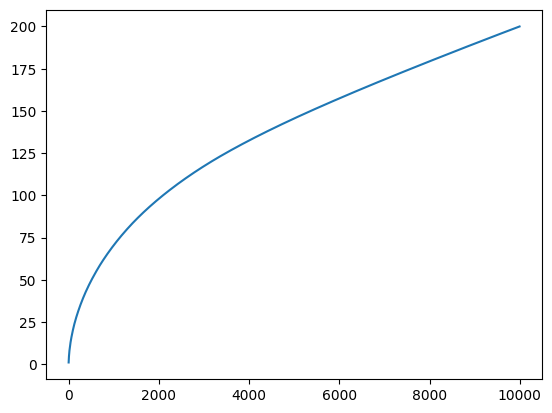

In [ ]:
tabla_pareto['comb'].plot()

In [ ]:
tabla_pareto.query(" comb >= 99.95 ")

,sales,sales_p,sales_p_ac,ranking,ranking_ac,ranking_p,comb
2090,269.36,0.01,79.05,2091,2187186,20.92,99.97
2091,268.94,0.01,79.06,2092,2189278,20.93,99.99
2092,268.70,0.01,79.07,2093,2191371,20.94,100.01
2093,268.58,0.01,79.08,2094,2193465,20.95,100.03
2094,268.24,0.01,79.09,2095,2195560,20.96,100.06
...,...,...,...,...,...,...,...
9989,0.88,0.00,100.00,9990,49905045,99.96,199.96
9990,0.85,0.00,100.00,9991,49915036,99.97,199.97
9991,0.84,0.00,100.00,9992,49925028,99.98,199.98
9992,0.56,0.00,100.00,9993,49935021,99.99,199.99


In [ ]:
tabla_pareto['diff_comb'] = (tabla_pareto['comb'] - 100).abs()

<Axes: >

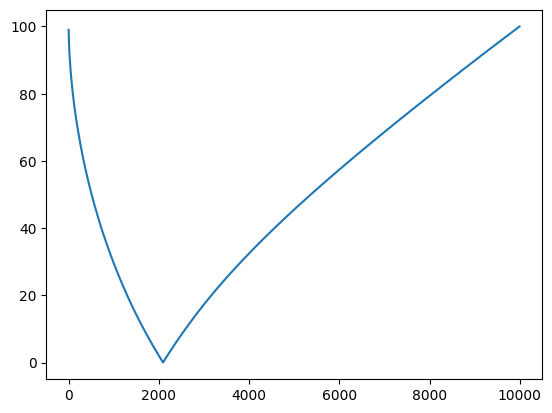

In [ ]:
tabla_pareto['diff_comb'].plot()

In [ ]:
fila_min = tabla_pareto['diff_comb'].idxmin()

In [ ]:
tabla_pareto.iloc[fila_min]

,2091
sales,268.94
sales_p,0.01
sales_p_ac,79.06
ranking,"2,092.00"
ranking_ac,"2,189,278.00"
ranking_p,20.93
comb,99.99
diff_comb,0.01


### Transformación logarítmica para datos sesgados

Al aplicar una transformación logarítmica (como `np.log`) a la variable `sales`, buscamos:

1. **Reducir el sesgo**: Los datos de ventas suelen tener una distribución muy sesgada hacia la derecha (muchas ventas pequeñas y pocas muy grandes). La transformación logarítmica ayuda a que la distribución se acerque más a una normal, lo cual es útil para muchos modelos estadísticos.
2. **Mitigar el impacto de valores atípicos (outliers)**: Los valores extremadamente grandes (outliers) en las ventas pueden dominar el análisis y distorsionar las medidas de tendencia central y dispersión. El logaritmo comprime estos valores, reduciendo su influencia.

Esto facilita una mejor visualización y análisis de los datos, haciendo que las relaciones entre variables sean más claras y las suposiciones de algunos modelos sean más válidas.

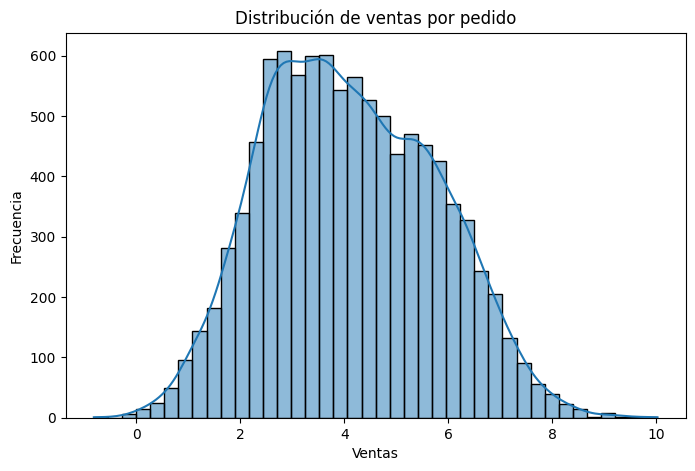

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(np.log(data["sales"]), bins=40, kde=True)
plt.title("Distribución de ventas por pedido")
plt.xlabel("Ventas")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
q1,q2,q3 = np.log(data["sales"]).quantile([0.25,0.5,0.75])

In [ ]:
iqr = q3 - q1
ls = q3 + 1.5*iqr
li = q1 - 1.5*iqr
prom = data.quantity.mean()
sd = data.quantity.std()

/tmp/ipykernel_2462/2363779757.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


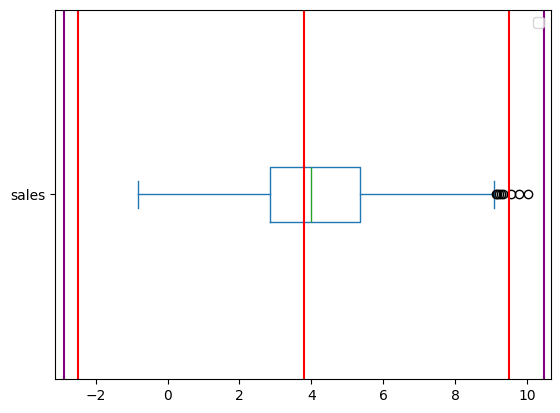

In [ ]:
np.log(data["sales"]).plot.box(vert=False)
plt.axvline(ls, color="red")
plt.axvline(li, color="red")
plt.axvline(prom, color="red")
plt.axvline(prom+3*sd, color="purple")
plt.axvline(prom-3*sd, color="purple")
plt.legend()
plt.show()

/tmp/ipykernel_2462/3549287378.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


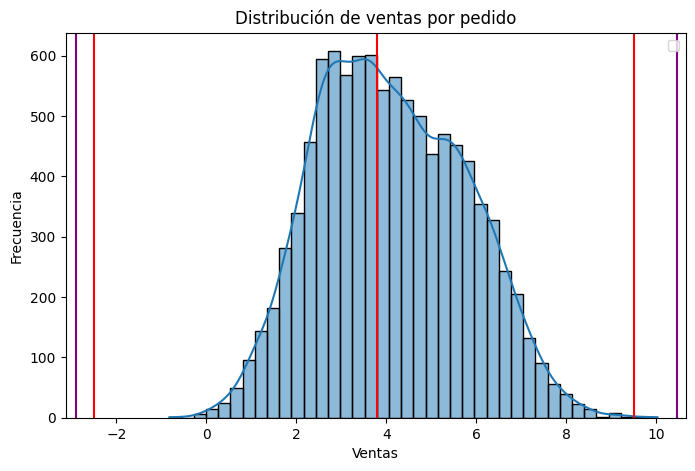

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(np.log(data["sales"]), bins=40, kde=True)
plt.title("Distribución de ventas por pedido")
plt.xlabel("Ventas")
plt.ylabel("Frecuencia")
plt.axvline(ls, color="red")
plt.axvline(li, color="red")
plt.axvline(prom, color="red")
plt.axvline(prom+3*sd, color="purple")
plt.axvline(prom-3*sd, color="purple")
plt.legend()
plt.show()
plt.show()

In [ ]:
data["sales"].describe()

,sales
count,"9,994.00"
mean,229.86
std,623.25
min,0.44
25%,17.28
50%,54.49
75%,209.94
max,"22,638.48"


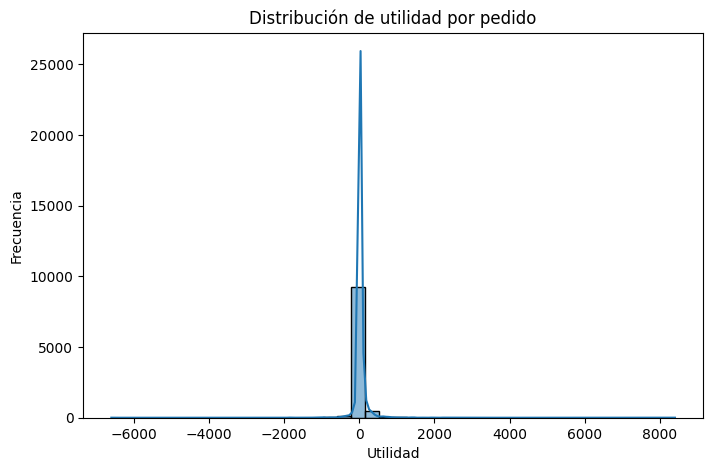

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data["profit"], bins=40, kde=True)
plt.title("Distribución de utilidad por pedido")
plt.xlabel("Utilidad")
plt.ylabel("Frecuencia")
plt.show()

## 11. Detección inicial de pérdidas

Una pregunta clave para el negocio es:

> ¿En qué registros la empresa vende, pero pierde dinero?

Filtraremos los pedidos con utilidad negativa para observar qué proporción representan y dónde se concentran.

In [ ]:
perdidas = data[data["profit"] < 0].copy()

print("Pedidos con pérdida:", perdidas.shape[0])
print("Porcentaje de pedidos con pérdida:", perdidas.shape[0] / data.shape[0])

perdidas.head()

Pedidos con pérdida: 1871
Porcentaje de pedidos con pérdida: 0.18721232739643787


,ship_mode,segment,country,city,state,postal_code,region,category,sub_category,sales,quantity,discount,profit
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.58,5.00,0.45,-383.03
14,Standard Class,Home Office,United States,Fort Worth,Texas,76106,Central,Office Supplies,Appliances,68.81,5.00,0.80,-123.86
15,Standard Class,Home Office,United States,Fort Worth,Texas,76106,Central,Office Supplies,Binders,2.54,3.00,0.80,-3.82
23,Second Class,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Furniture,Chairs,71.37,2.00,0.30,-1.02
27,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Furniture,Bookcases,"3,083.43",7.00,0.50,"-1,665.05"


In [ ]:
perdidas_categoria = (
    perdidas.groupby("category")
    .agg(
        ventas=("sales", "sum"),
        perdida_total=("profit", "sum"),
        pedidos=("profit", "count"),
        descuento_promedio=("discount", "mean")
    )
    .sort_values("perdida_total")
)

perdidas_categoria

,ventas,perdida_total,pedidos,descuento_promedio
category,,,,
Furniture,"257,885.73","-60,936.39",714,0.37
Office Supplies,"91,608.67","-56,615.43",886,0.62
Technology,"119,212.98","-38,580.04",271,0.33


## 12. Relación entre descuento y utilidad

Una hipótesis común en negocios es que descuentos altos pueden reducir la rentabilidad.

Construiremos un gráfico de dispersión para explorar la relación entre `discount` y `profit`.

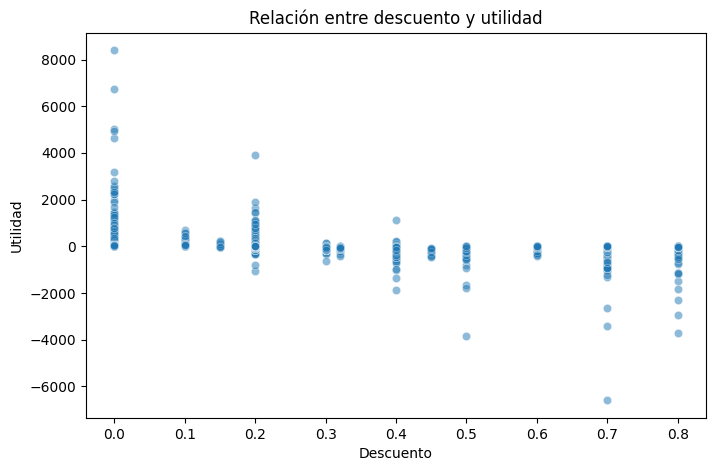

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x="discount", y="profit", alpha=0.5)
plt.title("Relación entre descuento y utilidad")
plt.xlabel("Descuento")
plt.ylabel("Utilidad")
plt.show()

In [ ]:
data[["discount", "sales", "quantity", "profit"]].corr()

,discount,sales,quantity,profit
discount,1.00,-0.03,0.01,-0.22
sales,-0.03,1.00,0.20,0.48
quantity,0.01,0.20,1.00,0.07
profit,-0.22,0.48,0.07,1.00


## 13. Ranking de subcategorías

Las subcategorías permiten un análisis más detallado que las categorías generales.

Aquí identificaremos:

- Subcategorías con más ventas.
- Subcategorías con mayor utilidad.
- Subcategorías con pérdida acumulada.

In [ ]:
resumen_subcategoria = (
    data.groupby("sub_category")
    .agg(
        ventas=("sales", "sum"),
        utilidad=("profit", "sum"),
        cantidad=("quantity", "sum"),
        descuento_promedio=("discount", "mean")
    )
    .assign(margen_utilidad=lambda x: x["utilidad"] / x["ventas"])
    .sort_values("utilidad", ascending=True)
)

resumen_subcategoria

,ventas,utilidad,cantidad,descuento_promedio,margen_utilidad
sub_category,,,,,
Tables,"206,965.68","-17,725.59","1,241.00",0.26,-0.09
Bookcases,"114,880.05","-3,472.56",868.00,0.21,-0.03
Supplies,"46,673.52","-1,188.99",647.00,0.08,-0.03
Fasteners,"3,024.25",949.53,914.00,0.08,0.31
Machines,"189,238.68","3,384.73",440.00,0.31,0.02
Labels,"12,486.30","5,546.18","1,400.00",0.07,0.44
Art,"27,118.80","6,527.96","3,000.00",0.07,0.24
Envelopes,"16,476.38","6,964.10",906.00,0.08,0.42
Furnishings,"91,705.12","13,059.25","3,563.00",0.14,0.14


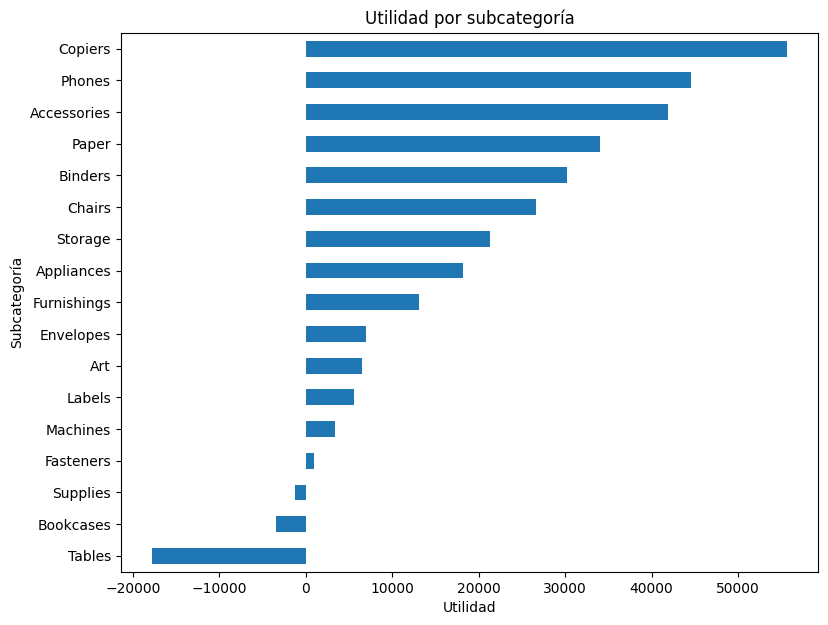

In [ ]:
resumen_subcategoria["utilidad"].plot(kind="barh", figsize=(9, 7))
plt.title("Utilidad por subcategoría")
plt.xlabel("Utilidad")
plt.ylabel("Subcategoría")
plt.show()

## 14. Comparación por segmento de cliente

El dataset también permite analizar segmentos de clientes.

Este tipo de análisis ayuda a responder:

- ¿Qué segmento compra más?
- ¿Qué segmento deja mayor utilidad?
- ¿Qué segmento recibe más descuento?

In [ ]:
resumen_segmento = (
    data.groupby("segment")
    .agg(
        ventas=("sales", "sum"),
        utilidad=("profit", "sum"),
        pedidos=("segment", "count"),
        descuento_promedio=("discount", "mean")
    )
    .assign(
        ticket_promedio=lambda x: x["ventas"] / x["pedidos"],
        margen_utilidad=lambda x: x["utilidad"] / x["ventas"]
    )
    .sort_values("ventas", ascending=False)
)

resumen_segmento

,ventas,utilidad,pedidos,descuento_promedio,ticket_promedio,margen_utilidad
segment,,,,,,
Consumer,"1,161,401.34","134,119.33",5191,0.16,223.73,0.12
Corporate,"706,146.44","91,979.45",3020,0.16,233.82,0.13
Home Office,"429,653.29","60,299.01",1783,0.15,240.97,0.14


## 15. Preguntas de interpretación para el alumno

Responde con base en los resultados obtenidos:

1. ¿Cuál es la categoría con mayores ventas?
2. ¿Cuál es la categoría con mayor utilidad?
3. ¿La región que más vende es también la más rentable?
4. ¿Qué subcategorías generan pérdidas acumuladas?
5. ¿Qué relación observas entre descuento y utilidad?
6. ¿Qué recomendación inicial darías a la empresa?

## 16. Conclusión orientativa

En este notebook se aplicó estadística descriptiva para convertir una tabla de ventas en información útil para la toma de decisiones.

El análisis exploratorio permitió revisar:

- Estructura del dataset.
- Medidas descriptivas básicas.
- Ventas y utilidad por categoría.
- Desempeño por región.
- Pedidos con pérdida.
- Relación entre descuento y utilidad.
- Ranking de subcategorías.

Recuerda que el análisis exploratorio no busca cerrar el problema, sino formular mejores preguntas para profundizar en una siguiente etapa.